# Customer Churn Prediction

## Model Training

### Objective

This notebook trains and compares several candidate models on the engineered feature set, using the metrics identified as appropriate during EDA (the ~80/20 class imbalance means accuracy alone would be misleading). Rather than choosing one model upfront, three qualitatively different candidates are trained and compared under identical evaluation conditions, and the strongest performer is carried forward for tuning and final evaluation.

**Models compared:**
- **Logistic Regression** - fast, interpretable baseline (uses the scaled feature set)
- **Random Forest** - handles non-linear relationships natively, e.g. the U-shaped products_number effect found in the EDA (uses the unscaled feature set)
- **Gradient Boosting (XGBoost if available, else scikit-learn's GradientBoostingClassifier)** - typically the strongest performer on tabular data (uses the unscaled feature set)

**Evaluation approach:**
- Stratified train/test split, so the ~20% churn rate is preserved in both sets
- Stratified k-fold cross-validation on the training set for model comparison
- ROC-AUC, Precision, Recall, and F1 as the deciding metrics
- A held-out test set for a final comparison before picking a model to carry forward


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

### Load the engineered datasets

The unscaled set for tree-based models, and the scaled set for logistic regression. Since both files contain the same rows in
the same order, splitting on the unscaled set's index and reusing it for the scaled set keeps the train/test split identical across both, this ensures every model is evaluated on exactly the same customers.

In [2]:
df_unscaled = pd.read_csv("../data/processed/bank_customer_churn_features.csv")
df_scaled = pd.read_csv("../data/processed/bank_customer_churn_features_scaled.csv")

print("Unscaled shape:", df_unscaled.shape)
print("Scaled shape:", df_scaled.shape)

df_unscaled.head()


Unscaled shape: (10000, 21)
Scaled shape: (10000, 21)


,credit_score,gender,age,tenure,balance,credit_card,active_member,estimated_salary,country_Germany,country_Spain,...,products_3,products_4,is_zero_balance,balance_to_salary_ratio,age_group_31-45,age_group_46-60,age_group_60+,tenure_by_age,products_active_interaction,churn
0,619,1,42,2,0.00,1,1,101348.88,0,0,...,0,0,1,0.000000,1,0,0,0.047619,1,1
1,608,1,41,1,83807.86,0,1,112542.58,0,1,...,0,0,0,0.744677,1,0,0,0.024390,1,0
2,502,1,42,8,159660.80,1,0,113931.57,0,0,...,1,0,0,1.401375,1,0,0,0.190476,0,1
3,699,1,39,1,0.00,0,0,93826.63,0,0,...,0,0,1,0.000000,1,0,0,0.025641,0,0
4,850,1,43,2,125510.82,1,1,79084.10,0,1,...,0,0,0,1.587055,1,0,0,0.046512,1,0


### Train/test split

A stratified split preserves the ~80/20 churn ratio in both the training and test sets. The same row indices are used for both the scaled and unscaled versions, so every model trains and is tested on identical customers.

In [3]:
X_unscaled = df_unscaled.drop(columns=["churn"])
X_scaled = df_scaled.drop(columns=["churn"])
y = df_unscaled["churn"]

# Split indices once on the unscaled data, then apply the same split to the scaled data
X_train_u, X_test_u, y_train, y_test, train_idx, test_idx = train_test_split(
    X_unscaled, y, X_unscaled.index,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train_s = X_scaled.loc[train_idx]
X_test_s = X_scaled.loc[test_idx]

print("Train shape:", X_train_u.shape, " Test shape:", X_test_u.shape)
print("Train churn rate: {:.2%}".format(y_train.mean()))
print("Test churn rate:  {:.2%}".format(y_test.mean()))


Train shape: (8000, 20)  Test shape: (2000, 20)
Train churn rate: 20.38%
Test churn rate:  20.35%


### Define candidate models

`class_weight="balanced"` is used for Logistic Regression and Random Forest to account for the ~80/20 imbalance without needing to resample the data. For the boosting model, `scale_pos_weight` (the ratio of negative to positive class counts) serves the same purpose
for XGBoost.

In [4]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": {
        "model": LogisticRegression(
            class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
        ),
        "X_train": X_train_s,
        "X_test": X_test_s,
    },
    "Random Forest": {
        "model": RandomForestClassifier(
            n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE
        ),
        "X_train": X_train_u,
        "X_test": X_test_u,
    },
    "XGBoost": {
        "model": XGBClassifier(
            n_estimators=300, scale_pos_weight=scale_pos_weight,
            eval_metric="logloss", random_state=RANDOM_STATE
        ),
        "X_train": X_train_u,
        "X_test": X_test_u,
    },
}

list(models.keys())


['Logistic Regression', 'Random Forest', 'XGBoost']

### Cross-validate each model on the training set

5-fold stratified cross-validation gives a more reliable comparison than a single train/test split, since it averages performance across five different train/validation partitions. This step is for **model selection** the held-out test set further below is reserved for a final, unbiased check on whichever model looks strongest here.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["roc_auc", "f1", "precision", "recall"]

cv_results = []

for name, spec in models.items():
    scores = cross_validate(
        spec["model"], spec["X_train"], y_train,
        cv=cv, scoring=scoring
    )
    cv_results.append({
        "Model": name,
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "F1": scores["test_f1"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("ROC-AUC", ascending=False)
cv_results_df


,Model,ROC-AUC,F1,Precision,Recall
1,Random Forest,0.851683,0.545781,0.750935,0.428834
0,Logistic Regression,0.842774,0.574869,0.467403,0.747239
2,XGBoost,0.834184,0.576786,0.613636,0.544785


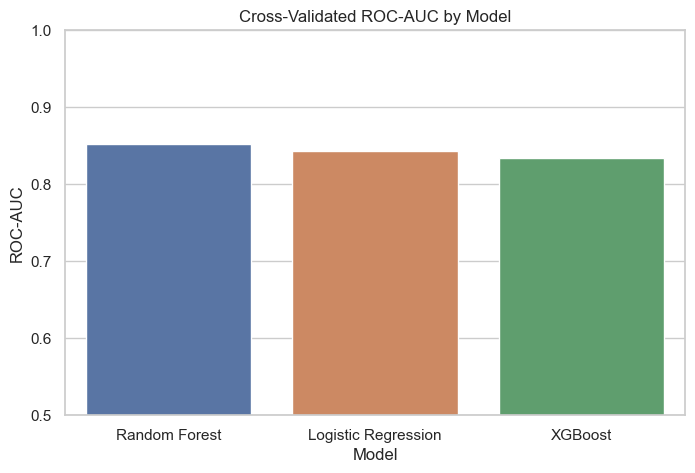

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(data=cv_results_df, x="Model", y="ROC-AUC")
plt.title("Cross-Validated ROC-AUC by Model")
plt.ylim(0.5, 1.0)
plt.savefig("../images/cv_roc_auc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


### Fit each model on the full training set and evaluate on the held-out test set

Cross-validation guided model selection; this step gives a final, honest read on performance using data no model has seen during training or tuning.

In [7]:
test_results = []
fitted_models = {}

for name, spec in models.items():
    model = spec["model"]
    model.fit(spec["X_train"], y_train)
    fitted_models[name] = model

    y_pred = model.predict(spec["X_test"])
    y_proba = model.predict_proba(spec["X_test"])[:, 1]

    test_results.append({
        "Model": name,
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "F1": f1_score(y_test, y_pred),
    })

    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))

test_results_df = pd.DataFrame(test_results).sort_values("ROC-AUC", ascending=False)
test_results_df


--- Logistic Regression ---
              precision    recall  f1-score   support

    Retained       0.92      0.79      0.85      1593
     Churned       0.47      0.74      0.57       407

    accuracy                           0.78      2000
   macro avg       0.69      0.76      0.71      2000
weighted avg       0.83      0.78      0.79      2000

--- Random Forest ---
              precision    recall  f1-score   support

    Retained       0.87      0.97      0.92      1593
     Churned       0.78      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000

--- XGBoost ---
              precision    recall  f1-score   support

    Retained       0.89      0.90      0.89      1593
     Churned       0.58      0.56      0.57       407

    accuracy                           0.83      2000
   macro avg       0.74      0.73      0.73      2000
weighted

,Model,ROC-AUC,F1
1,Random Forest,0.852689,0.570983
0,Logistic Regression,0.844492,0.571973
2,XGBoost,0.820387,0.570352


### Confusion matrices

These show the actual trade-off each model makes between false positives (flagging a customer who was going to stay) and false negatives (missing a customer who was going to churn). In a retention context, false negatives are usually the costlier mistake, since a
missed churner is a lost customer with no intervention attempted.

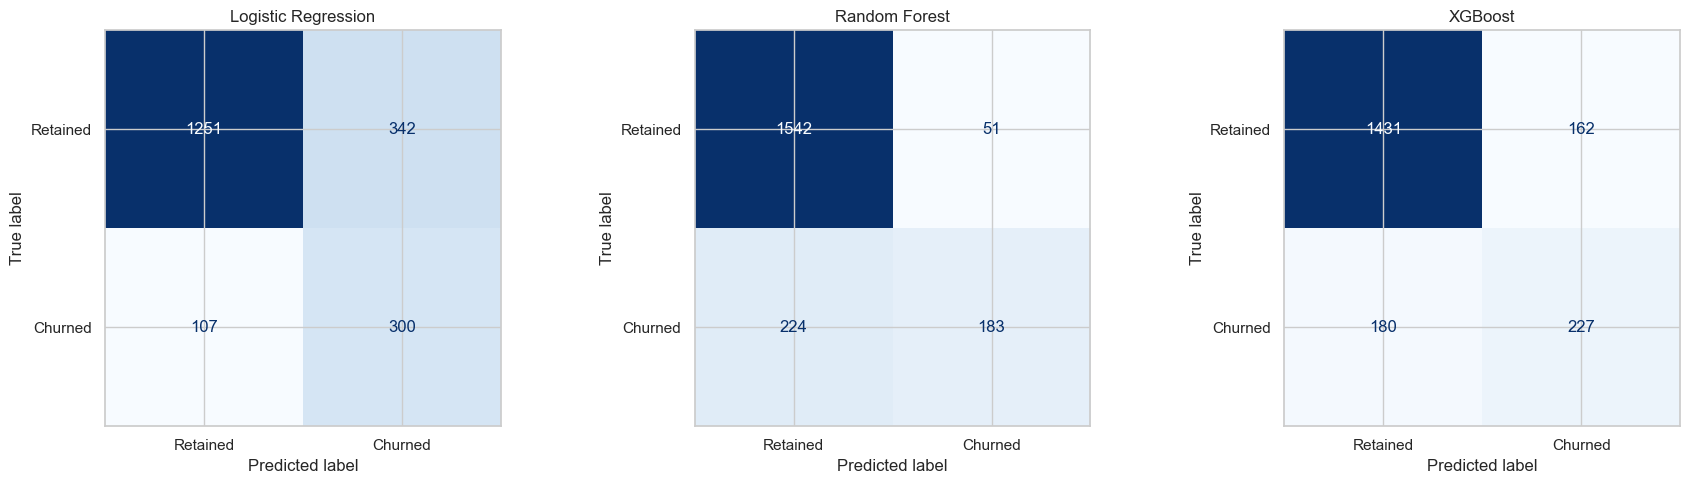

In [8]:
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5))
if len(models) == 1:
    axes = [axes]

for ax, (name, spec) in zip(axes, models.items()):
    model = fitted_models[name]
    y_pred = model.predict(spec["X_test"])
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Retained", "Churned"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(name)

plt.tight_layout()
plt.savefig("../images/confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()


### ROC curve comparison

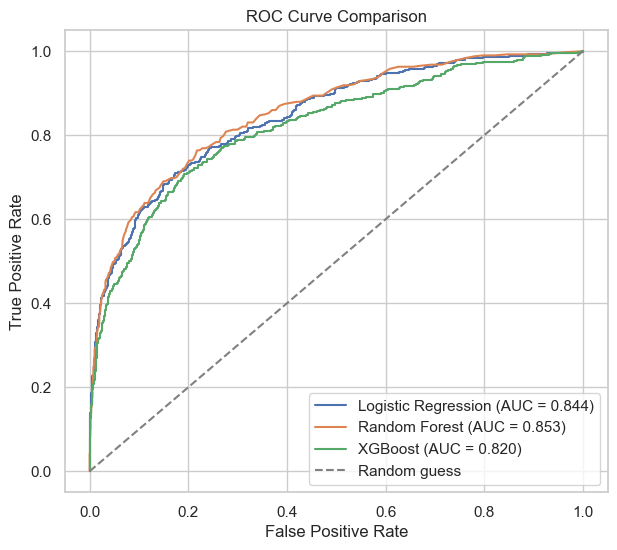

In [9]:
plt.figure(figsize=(7, 6))

for name, spec in models.items():
    model = fitted_models[name]
    y_proba = model.predict_proba(spec["X_test"])[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig("../images/roc_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


### Feature importance (tree-based models)

Feature importance from the tree-based models offers a check against the EDA and feature engineering assumptions: do the features expected to matter most (age, active membership, balance, products) actually come out on top?

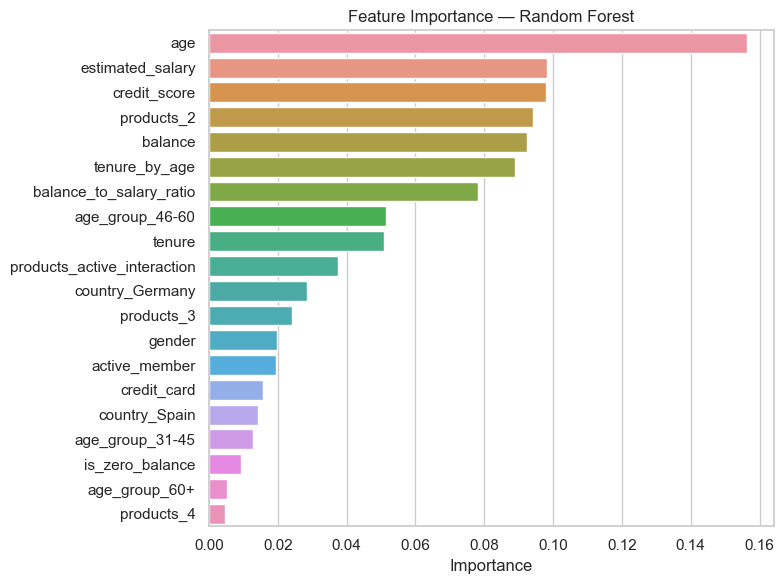

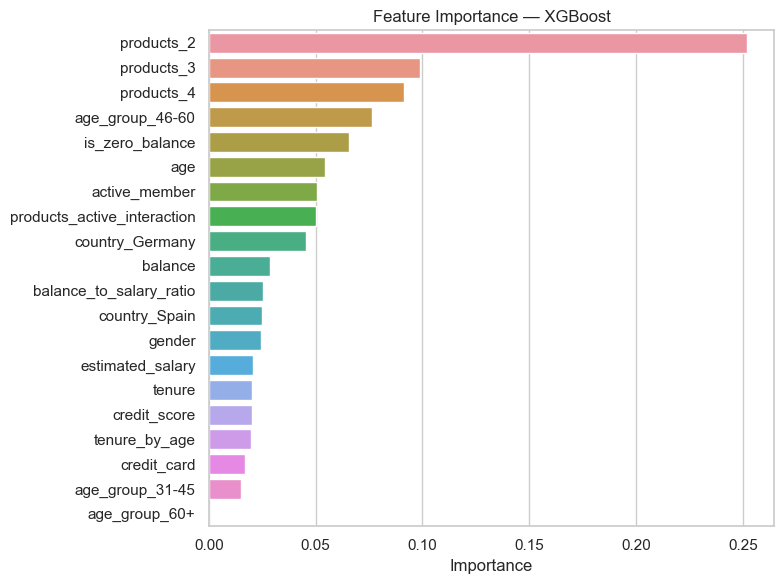

In [10]:
tree_models = {name: m for name, m in fitted_models.items()
               if hasattr(m, "feature_importances_")}

for name, model in tree_models.items():
    importances = pd.Series(
        model.feature_importances_, index=models[name]["X_train"].columns
    ).sort_values(ascending=False)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=importances.values, y=importances.index)
    plt.title(f"Feature Importance — {name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig(f"../images/feature_importance_{name.replace(' ', '_').lower()}.png",
                dpi=300, bbox_inches="tight")
    plt.show()


### Select and save the best model

The model with the highest test-set ROC-AUC is saved as `trained_model.pkl` for use in model evaluation. ROC-AUC is used as the selection criterion since it summarizes ranking ability across all thresholds, which matters if a specific precision/recall trade-off is tuned later (e.g. adjusting the decision threshold based on the cost of missing a churner versus over-flagging retained customers).

In [11]:
best_model_name = test_results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

print(f"Best model by test ROC-AUC: {best_model_name}")
print(test_results_df)

with open("../models/trained_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print(f"\nSaved {best_model_name} to ../models/trained_model.pkl")


Best model by test ROC-AUC: Random Forest
                 Model   ROC-AUC        F1
1        Random Forest  0.852689  0.570983
0  Logistic Regression  0.844492  0.571973
2              XGBoost  0.820387  0.570352

Saved Random Forest to ../models/trained_model.pkl


## Summary

**Model comparison:** All three models perform similarly well by ROC-AUC (0.82–0.85) and F1 (~0.57), but differ sharply in how they trade off precision and recall for the churn class. Random Forest has the highest raw ROC-AUC (0.853) but the weakest recall (0.45), missing over half of actual churners at its default threshold. Logistic Regression has the best recall (0.74) but the weakest precision (0.47). This gap matters because catching churners is the primary business goal — missing one is a lost customer, while a false alarm is a lower-cost mistake (an unnecessary retention offer to a loyal customer).

**Decision:** Random Forest is carried forward for its stronger ranking ability (ROC-AUC), but its default 0.5 threshold under-catches churners. 06_model_evaluation.ipynb will tune the classification threshold to shift Random Forest's recall upward before treating it as final rather than accepting its out-of-the-box precision/recall trade-off.

**Feature importance caveat:** Random Forest's impurity-based feature importance ranks estimated_salary and credit_score unexpectedly high, contradicting their near-zero correlation with churn in the EDA, a known bias of this metric toward continuous variables. XGBoost's importance ranking is more consistent with EDA findings (products_number, age groups, zero balance dominate) and should be considered more reliable for interpretation. Permutation importance is recommended for a trustworthy final read in the next notebook.
